In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## METRICS MEASUREMENTS

In [8]:
organisms = ["hiv","sars","denv","hbv","monkeypox"]

for org in organisms:
    print(f"\n>> {org}")
    path = f"/home/salipe/Desktop/GREAC/GREAC/output-7/benchmark_results_{org}.csv"
    data = pd.read_csv(path)

    metrics = ["final_len","macro_f1","macro_precision","macro_recall"]
    for metric in metrics:
        print(f'{metric} mean = {data[metric].mean():.4f} std = ({data[metric].std():.4f})')


>> hiv
final_len mean = 8857.6200 std = (58.1688)
macro_f1 mean = 0.9890 std = (0.0064)
macro_precision mean = 0.9873 std = (0.0078)
macro_recall mean = 0.9912 std = (0.0054)

>> sars
final_len mean = 9587.8500 std = (53.6497)
macro_f1 mean = 0.9595 std = (0.0219)
macro_precision mean = 0.9362 std = (0.0301)
macro_recall mean = 0.9969 std = (0.0020)

>> denv
final_len mean = 10491.3000 std = (382.6704)
macro_f1 mean = 0.9889 std = (0.0039)
macro_precision mean = 0.9824 std = (0.0068)
macro_recall mean = 0.9959 std = (0.0016)

>> hbv
final_len mean = 3120.5192 std = (17.1470)
macro_f1 mean = 0.9987 std = (0.0030)
macro_precision mean = 0.9980 std = (0.0050)
macro_recall mean = 0.9994 std = (0.0005)

>> monkeypox
final_len mean = 54588.0000 std = (0.0000)
macro_f1 mean = 0.9600 std = (0.0110)
macro_precision mean = 0.9340 std = (0.0166)
macro_recall mean = 0.9910 std = (0.0026)


## ACCURACY MEASUREMENTS

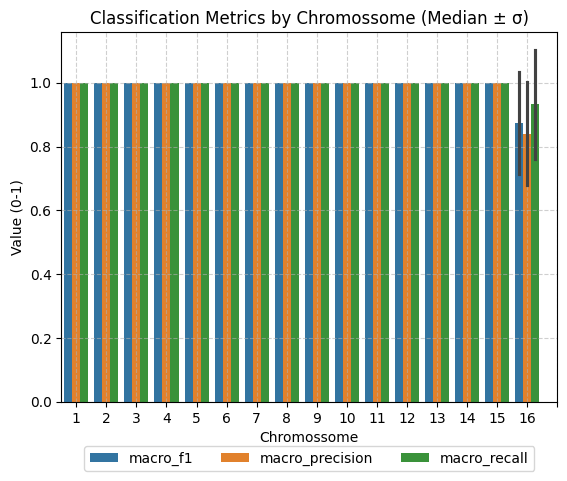

In [27]:

all_data = []

for i in range(1,17):
    sars_vars_path = f"/home/salipe/Documents/IPB/medibees/benchmarks/benchmark_results_bees{i}.csv"
    data = pd.read_csv(sars_vars_path)

    data["wndwPercent"] = data["wndwPercent"].astype("float128")

    data["chromossome"] = i  # adicionar coluna do cromossomo

    # Selecionar apenas as métricas de interesse
    subset = data[["chromossome", "macro_f1", "macro_precision", "macro_recall"]]
    all_data.append(subset)
  
    line = ""
    for metric in ["final_len","windows","kmerset","macro_f1","macro_precision","macro_recall"]:
        # print(f' {i} {metric}: mean = {data[metric].mean():.4f} std = ({data[metric].std():.4f})')
        line = f"{line} & {data[metric].mean():.2f} ({data[metric].std():.2f})"
    # print(line)
    # print('-------------------')

df_all = pd.concat(all_data, ignore_index=True)

# Transformar em formato tidy
df_melted = df_all.melt(
    id_vars="chromossome", 
    value_vars=["macro_f1", "macro_precision", "macro_recall"],
    var_name="metric", 
    value_name="value"
)

# Plot com desvio padrão como sombra
fig = plt.figure()
sns.barplot(
    data=df_melted, 
    x="chromossome", 
    y="value", 
    hue="metric", 
    errorbar="sd",   
)

plt.title("Classification Metrics by Chromossome (Median ± σ)")
plt.xlabel("Chromossome")
plt.xticks(range(0,17))
plt.ylabel("Value (0-1)")
plt.legend(
    loc="upper center",       # centraliza horizontalmente
    bbox_to_anchor=(0.5, -0.1), # posiciona acima do gráfico (ajuste o 1.08 conforme precisar)
    ncol=3                    # coloca tudo em uma linha
)
plt.grid(True, linestyle="--", alpha=0.6)


fig.savefig(f"chormossomo_lineage_metric_comparison.pdf", bbox_inches="tight")
plt.show()

## LINEAGE MUTATION LIST

In [6]:
gramep = ['AY.3',
'AY.25',
'AY.44',   
'AY.103',  
'B.1' ,
'B.1.1.7', 
'B.1.526', 
'B.1.2', 
'BA.1',  
'BA.1.1',  
'BA.1.15',  
'BA.1.18' , 
'BA.2',
'BA.2.12.2', 
'BA.4.6' ,
'BA.5.1' ,
'BA.5.2',
'BA.5.2.1' ,
'BA.5.5', 
'BQ.1.1' ]

kevolve=['B.1.1.7',
         'B.1.351',
         'P.1',
         'B.1.617.2',
         'B.1.617.1',
         'B.1.427','B.1.429',
         'B.1.526',
         'B.1.525',
         'C.37',
         'B.1.1.529',
         'BA.1.15','BA.1.18','BA.1.1','BA.2.12.1','BA.4.6','BA.5.1','BA.5.2.1','BA.5.2','BA.5.5']

In [28]:


mutations_file = '/home/salipe/Desktop/datasets/mutation_distribution_in_lineages.txt'

threshold = 0.99

mutations_df = pd.read_table(mutations_file, sep='\t', usecols=['Lineage',
                                                                    'Frequency of mutated sequences per Lineage',
                                                                    'Genome position',
                                                                    'Ref seq',
                                                                    'ut seq'])
                                                                    
mutations = mutations_df[(mutations_df['Lineage'].isin(sum([gramep],kevolve))) & (mutations_df['Frequency of mutated sequences per Lineage'] >= threshold)] 

In [30]:
mutations.to_csv("teste", index=False)

In [ ]:
ls = mutations['Genome position'].to_list()
ls = list(set(ls))
ls.sort()
print(len(ls))

set(sum([gramep],kevolve))

83

## DENV annotation file positions 

In [7]:

denv = '/home/salipe/Desktop/datasets/denv/annotation.gff3'

gff = pd.read_csv(denv, sep="\t", comment="#", header=None,
                  names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

# Filtra genes (ou qualquer outro tipo)
genes = gff[gff["type"].isin(["exon","CDS","mature_protein_region_of_CDS","five_prime_UTR","three_prime_UTR"])]

# Cria lista de dicionários
dados = []
tupples = []
for idx, row in genes.iterrows():
    atributos = row['attributes']
    
    # Opcional: extrai ID e Name dos atributos
    attr_dict = dict(item.split("=") for item in atributos.split(";") if "=" in item)
    
    tupples.append((row["start"],row["end"]))

    dados.append({
        "seqid": row["seqid"],
        "start": row["start"],
        "end": row["end"],
        "type": row["type"]
    })
df = pd.DataFrame(dados)
df


,seqid,start,end,type
0,NC_001477.1,1,94,five_prime_UTR
1,NC_001477.1,95,10273,CDS
2,NC_001477.1,95,436,mature_protein_region_of_CDS
3,NC_001477.1,95,394,mature_protein_region_of_CDS
4,NC_001477.1,437,934,mature_protein_region_of_CDS
5,NC_001477.1,437,709,mature_protein_region_of_CDS
6,NC_001477.1,710,934,mature_protein_region_of_CDS
7,NC_001477.1,935,2419,mature_protein_region_of_CDS
8,NC_001477.1,2420,3475,mature_protein_region_of_CDS
9,NC_001477.1,3476,4129,mature_protein_region_of_CDS


## FIT PARAMETERS ANALYSIS

['./parameters_optimizations/sars_parameter_optimization_20260111.csv']
MELHORES PARÂMETROS
Window: 0.002
Threshold: 80
K-mer: 7
Metric: manhattan
F1-Score: 0.9814
['./parameters_optimizations/denv_parameter_optimization_20260110.csv']
MELHORES PARÂMETROS
Window: 0.0015
Threshold: 75
K-mer: 7
Metric: manhattan
F1-Score: 0.9973
['./parameters_optimizations/mkpx_parameter_optimization_20260124.csv']
MELHORES PARÂMETROS
Window: 0.001
Threshold: 70
K-mer: 7
Metric: manhattan
F1-Score: 0.9780
['./parameters_optimizations/hbv_parameter_optimization_20260125.csv']
MELHORES PARÂMETROS
Window: 0.002
Threshold: 60
K-mer: 7
Metric: manhattan
F1-Score: 0.9999
['./parameters_optimizations/hiv_parameter_optimization_20251229.csv']
MELHORES PARÂMETROS
Window: 0.002
Threshold: 70
K-mer: 7
Metric: manhattan
F1-Score: 0.9448


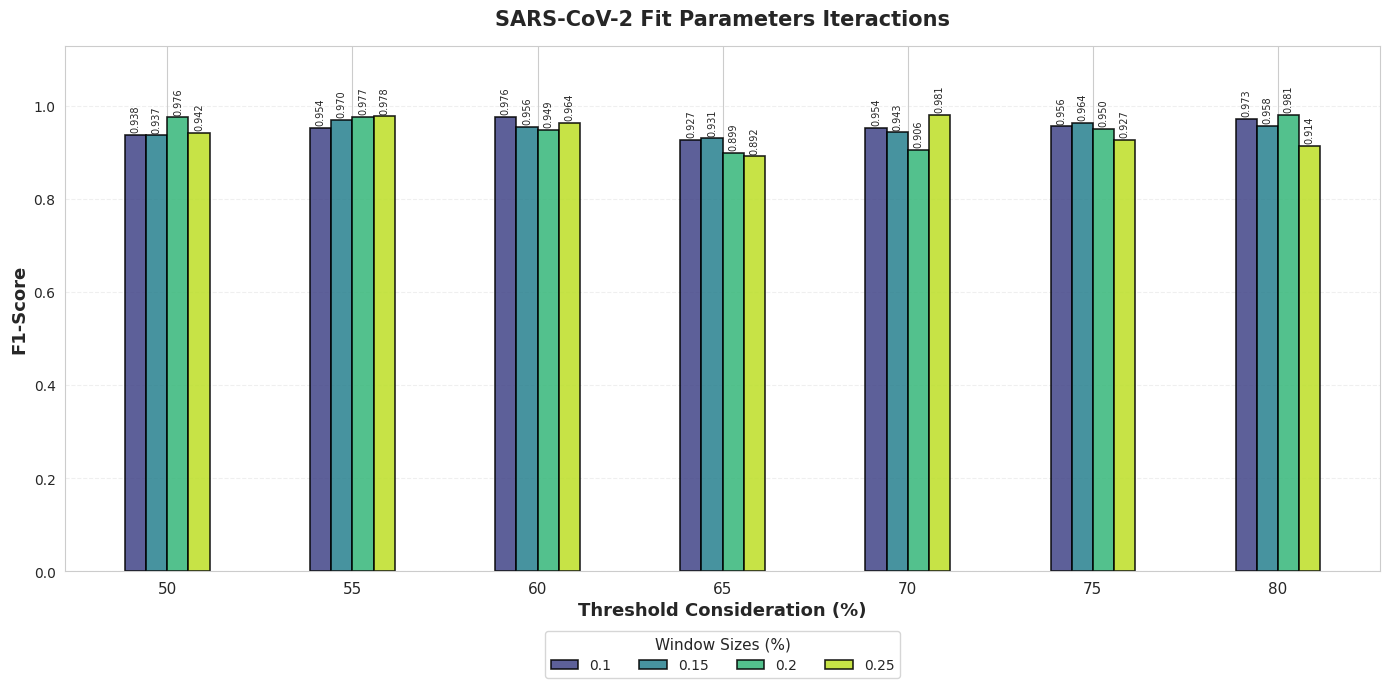

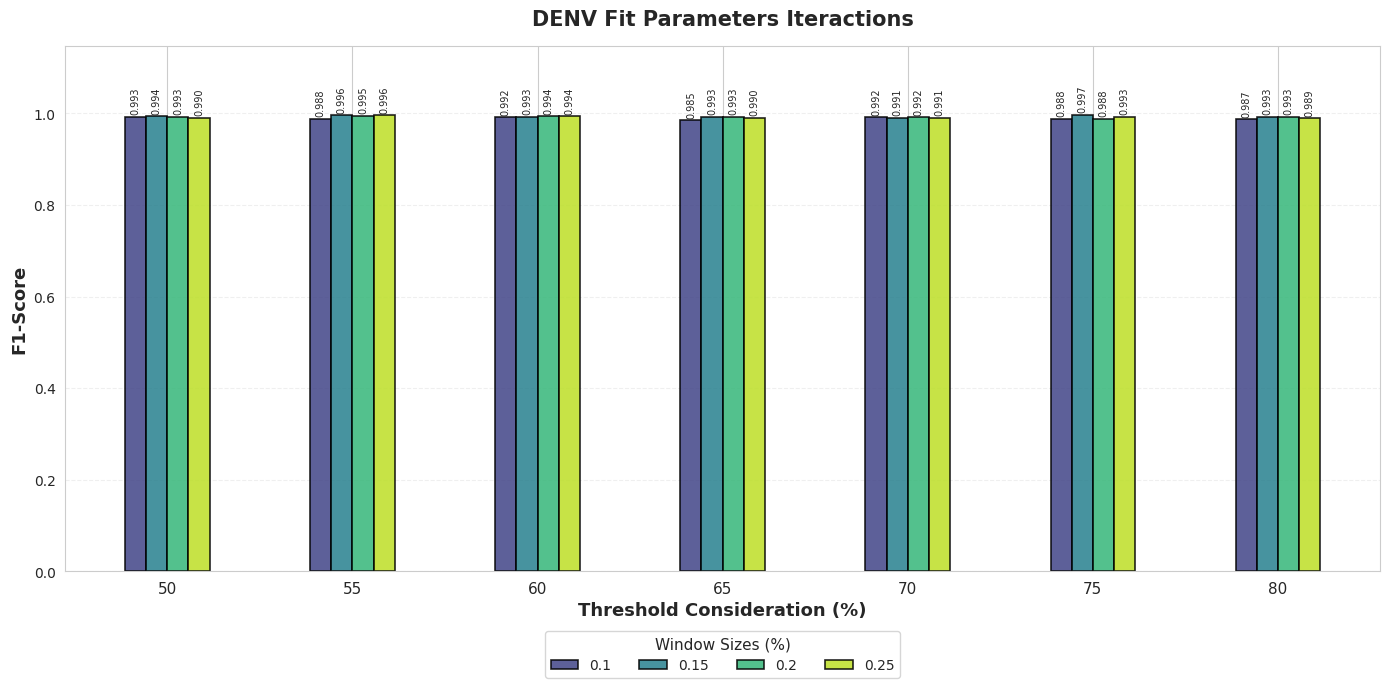

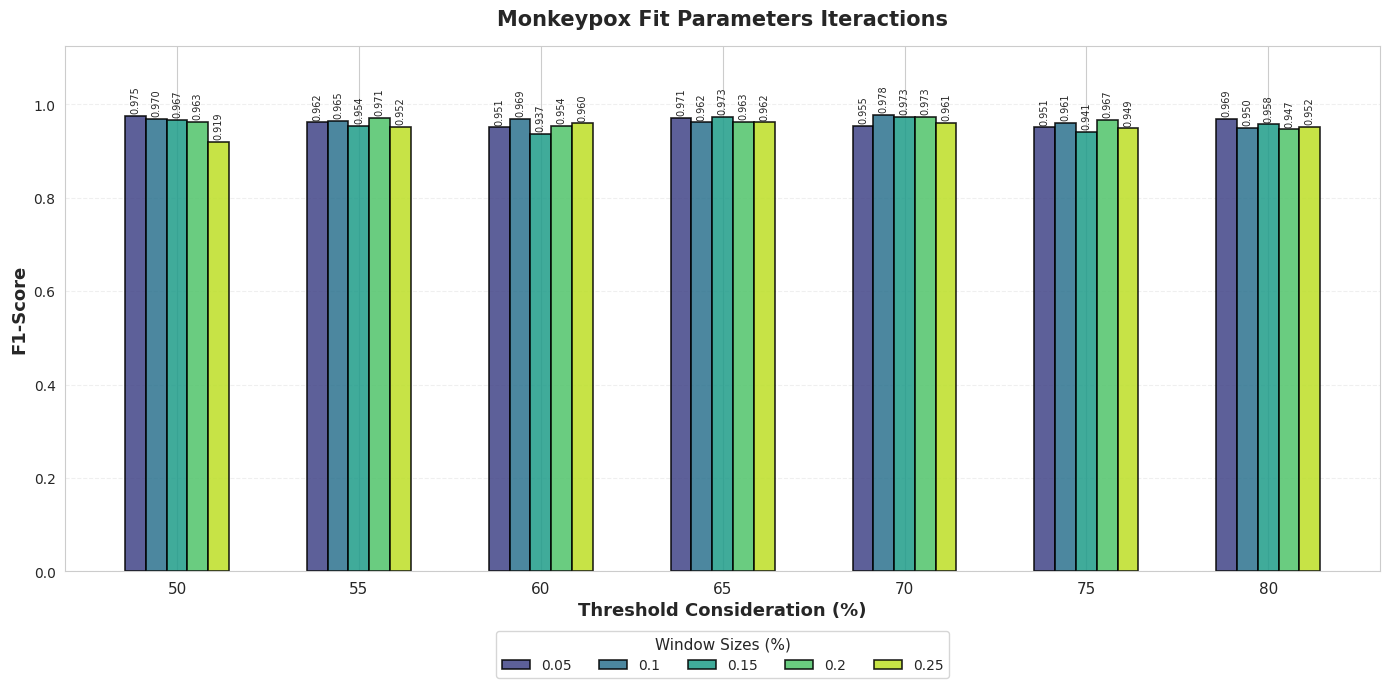

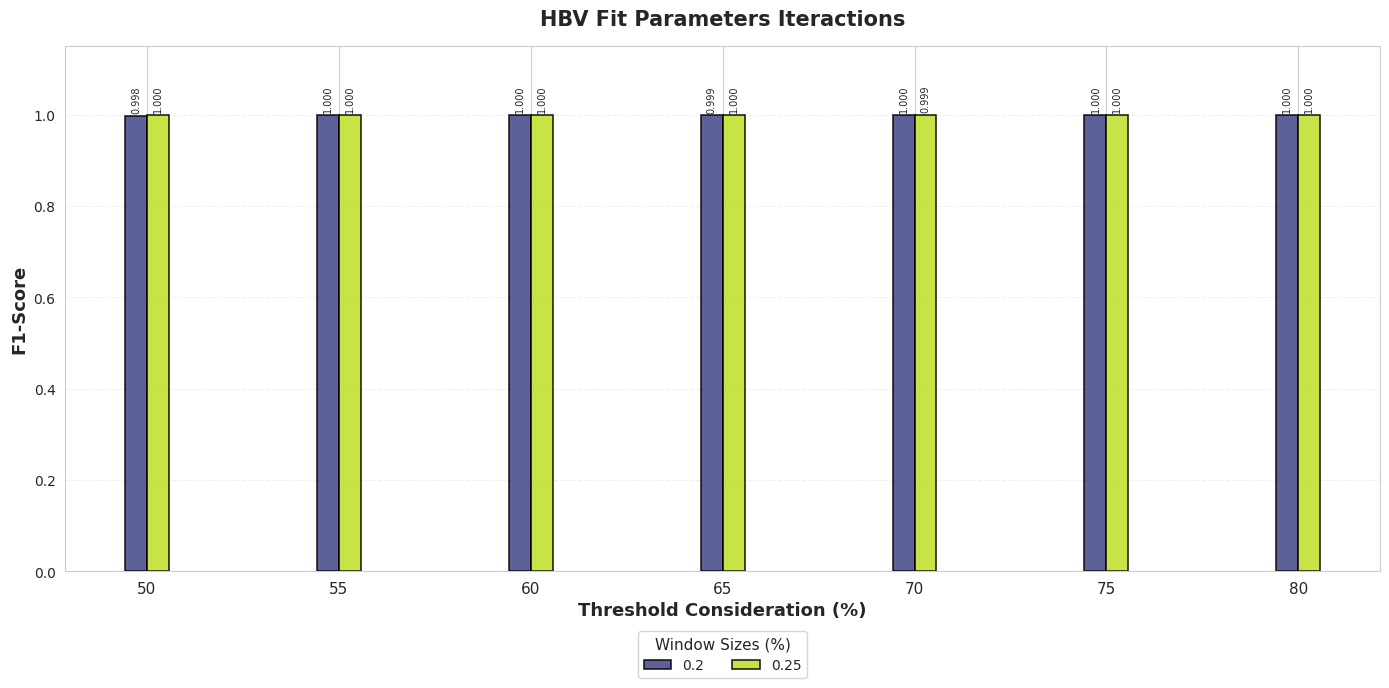

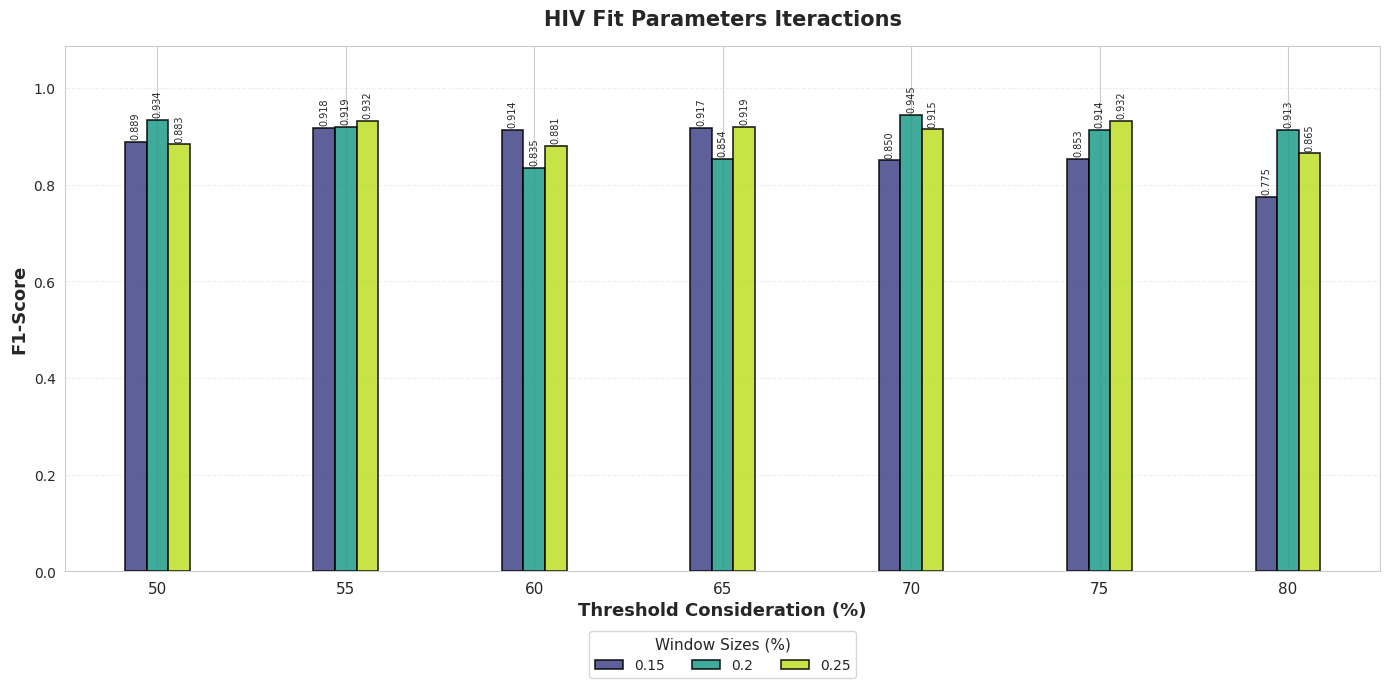

In [33]:
vars = {
    "sars":"SARS-CoV-2",
    "denv":"DENV",
    "mkpx":"Monkeypox",
    "hbv":"HBV",
    "hiv":"HIV",
}

for var in vars:
    nome = vars[var]
    var = var
    file_path = f"./parameters_optimizations/{var}_parameter_optimization_*.csv"

    path = glob.glob(file_path)
    print(path)
    df  = pd.read_csv(path[0])

    df["window"] = df["window"].astype(float).round(4)
    df["threshold"] = df["threshold"].astype(float)* 100
    df["threshold"] = df["threshold"].round(0)
    df["threshold"] = df["threshold"].astype(int)

    best_idx = df['f1_score'].idxmax()
    best_params = df.loc[best_idx]

    print("=" * 60)
    print("MELHORES PARÂMETROS")
    print("=" * 60)
    print(f"Window: {best_params['window']}")
    print(f"Threshold: {best_params['threshold']}")
    print(f"K-mer: {best_params['kmer']}")
    print(f"Metric: {best_params['metric']}")
    print(f"F1-Score: {best_params['f1_score']:.4f}")
    print("=" * 60)

    # Configurar estilo dos gráficos
    sns.set_style("whitegrid")

    # Agrupar por window e threshold
    grouped = df.groupby(['window', 'threshold'])['f1_score'].mean().reset_index()

    # Obter valores únicos
    windows = sorted(grouped['window'].unique())
    thresholds = sorted(grouped['threshold'].unique())

    # Configurar posições das barras
    n_windows = len(windows)
    n_thresholds = len(thresholds)
    bar_width = 0.8 / n_thresholds
    x = np.arange(n_thresholds)

    # Criar figura
    fig, ax = plt.subplots(figsize=(14, 7))

    # Cores para diferentes windows
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_windows))

    # Plotar barras para cada threshold
    for i, window in enumerate(windows):
        data = grouped[grouped['window'] == window]

        # Ordenar por window
        data = data.set_index('threshold').reindex(thresholds).reset_index()
        
        positions = x + (i - n_windows/2 + 0.5) * bar_width
        bars = ax.bar(positions, data['f1_score'], bar_width, 
                    label=f'{window*100}',
                    color=colors[i], edgecolor='black', linewidth=1.2, alpha=0.85)
        
        # Adicionar valores no topo das barras (opcional, apenas para barras mais altas)
        for j, (pos, val) in enumerate(zip(positions, data['f1_score'])):
            if pd.notna(val) and val > 0:
                ax.text(pos, val + 0.005, f'{val:.3f}', 
                    ha='center', va='bottom', fontsize=7, rotation=90)

    # Configurar eixos e títulos
    ax.set_xlabel('Threshold Consideration (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
    ax.set_title(f'{nome} Fit Parameters Iteractions', 
                fontsize=15, fontweight='bold', pad=15)

    ax.set_xticks(x)
    ax.set_xticklabels(thresholds, fontsize=11)

    ax.legend(title='Window Sizes (%)', fontsize=10, title_fontsize=11, 
            loc="upper center",       # centraliza horizontalmente
                bbox_to_anchor=(0.5, -0.1), # posiciona acima do gráfico (ajuste o 1.08 conforme precisar)
                ncol=5 )


    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, grouped['f1_score'].max() * 1.15])

    plt.tight_layout()
    plt.savefig(f'{var}_analise_window_threshold.png', dpi=300, bbox_inches='tight')
    # plt.show()
